## Intial imports and setup 

In [1]:
import os
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm
import random
import shutil
from collections import Counter

In [2]:
# Paths to the label file and the image directory
labels_path = './Dataset/trainLabels.csv'
images_dir = './Dataset/resized_train/resized_train'

# Load labels
labels_df = pd.read_csv(labels_path)


In [3]:
labels_df.head()

,image,level
0,10_left,0
1,10_right,0
2,13_left,0
3,13_right,0
4,15_left,1


## Dataset Mapping 

In [4]:
# Drop unnecessary columns if they exist
if 'Unnamed: 0' in labels_df.columns or 'Unnamed: 0.1' in labels_df.columns:
    labels_df = labels_df.drop(columns=['Unnamed: 0', 'Unnamed: 0.1'], errors='ignore')

# Adding a new column to the labels DataFrame to include label descriptions
label_descriptions = {
    0: "No disease",
    1: "Mild",
    2: "Moderate",
    3: "Severe",
    4: "Proliferate"
}

# Map the descriptions to a new column based on the 'level' column
labels_df['description'] = labels_df['level'].map(label_descriptions)


In [5]:
# Sort the labels_df by 'image' column to ensure order matches folder
labels_df = labels_df.sort_values('image').reset_index(drop=True)

# Create a dictionary to map image names to labels
labels_dict = dict(zip(labels_df['image'], labels_df['description']))


## Preprocess Images

In [6]:
# Function to load and preprocess images
def load_image(image_name, target_size=(224, 224)):
    image_path = os.path.join(images_dir, f"{image_name}.jpeg")
    image = cv2.imread(image_path)
    if image is None:
        print(f"Image {image_name} not found.")
        return None
    # Resize the image if required
    image = cv2.resize(image, target_size)
    # Convert BGR to RGB
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    return image


## Visualize the labeled images

In [7]:
def visualize_samples(sample_size=8):
    sample_images = random.sample(list(labels_dict.keys()), sample_size)
    plt.figure(figsize=(16, 8))
    
    # Display each sample image
    for i, image_name in enumerate(sample_images):
        image = load_image(image_name)
        if image is not None:
            plt.subplot(2, 4, i + 1)  # This will arrange images in 2 rows and 4 columns
            plt.imshow(image)
            plt.title(f"Label: {labels_dict.get(image_name, 'Unknown')}")
            plt.axis('off')
            
    plt.tight_layout()
    plt.show()


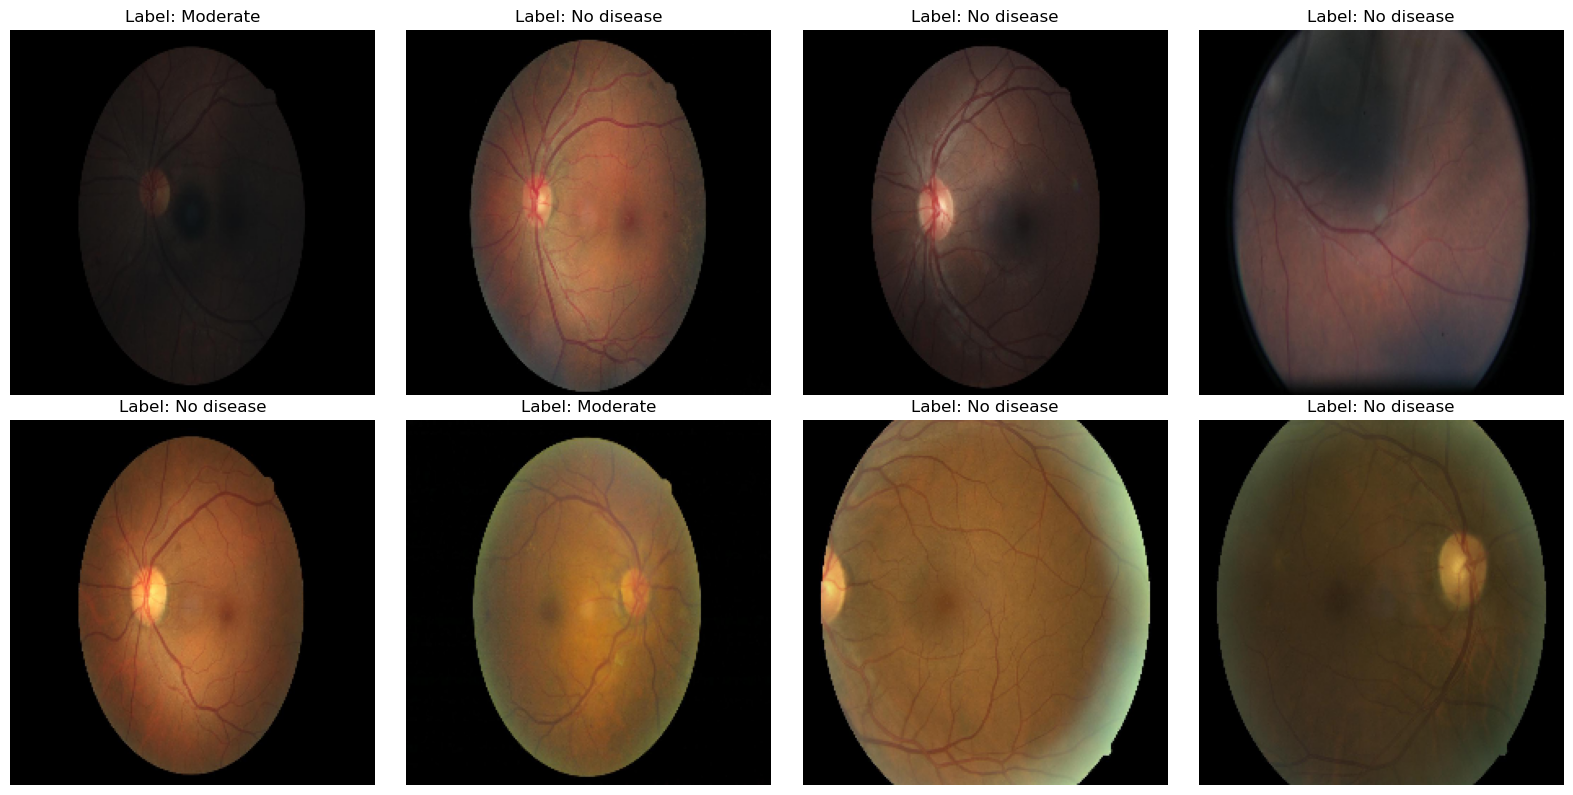

In [8]:
# Call the function to visualize samples
visualize_samples()


In [9]:
# Initialize a counter for categories
category_counter = Counter()

# Loop through each image in labels_dict to count the categories of successfully loaded images
for image_name, description in labels_dict.items():
    image_path = os.path.join(images_dir, f"{image_name}.jpeg")
    if os.path.exists(image_path):  # Check if the image file exists
        category_counter[description] += 1

# Print the total count of images in each category
print("Total number of images in each category (based on available images):")
for category, count in category_counter.items():
    print(f"{category}: {count}")


Total number of images in each category (based on available images):
No disease: 25810
Proliferate: 708
Severe: 873
Moderate: 5292
Mild: 2443


## Storing the resized images

In [13]:
# Main directory and subdirectory to store curated, resized images
main_dir = './Dataset'
resized_images_dir = os.path.join(main_dir, 'resize_images')
os.makedirs(resized_images_dir, exist_ok=True)

# Filter "No disease" images and randomly select 15,000 to remove
no_disease_images = [img for img, label in labels_dict.items() if label == "No disease"]
remove_images = set(random.sample(no_disease_images, 15000))

# Filtered labels dictionary (excluding removed images)
filtered_labels_dict = {img: label for img, label in labels_dict.items() if img not in remove_images}

# Function to normalize and save images
def normalize(image):
    return image / 255.0

# Resize, normalize, and save images in the resize_images directory
def preprocess_and_save_images():
    for image_name, description in tqdm(filtered_labels_dict.items()):
        image_path = os.path.join(images_dir, f"{image_name}.jpeg")
        image = cv2.imread(image_path)
        
        if image is not None:
            # Resize image to 244x244
            resized_image = cv2.resize(image, (244, 244))
            # Normalize the image
            normalized_image = normalize(resized_image)
            # Convert to 8-bit format to save
            final_image = (normalized_image * 255).astype('uint8')
            
            # Save path for resized image in the resize_images folder
            save_path = os.path.join(resized_images_dir, f"{image_name}.jpeg")
            cv2.imwrite(save_path, final_image)

# Run the preprocessing function
preprocess_and_save_images()


100%|██████████| 20126/20126 [00:47<00:00, 424.80it/s]


In [14]:
# Directory containing the resized images
resized_images_dir = './Dataset/resize_images'

# Counter for total images and per-category counts
total_images = 0
category_counts = Counter()

# Count images based on the labels in filtered_labels_dict
for image_name, label in filtered_labels_dict.items():
    image_path = os.path.join(resized_images_dir, f"{image_name}.jpeg")
    if os.path.exists(image_path):
        total_images += 1
        category_counts[label] += 1

# Display results
print(f"Total images in 'resize_images' folder: {total_images}")
print("Number of images in each category:")
for category, count in category_counts.items():
    print(f"{category}: {count}")


Total images in 'resize_images' folder: 20126
Number of images in each category:
No disease: 10810
Proliferate: 708
Severe: 873
Moderate: 5292
Mild: 2443
